# Notebook 7 — DistilRoBERTa Fine-Tuning

## Environment Setup for DistilRoBERTa Experiments

This section prepares the environment for training a lightweight transformer model. Required libraries for modelling, tokenisation, and evaluation are initialised.

Configuration parameters are imported to ensure consistent use of paths, hyperparameters, and experimental settings. Output directories are created for storing model checkpoints and visualisations.

The computation device is selected dynamically to utilise available hardware efficiently.

In [1]:
# Path setup for config import
import sys, os, pickle, time, copy
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# PyTorch modules
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformer utilities
from transformers import (
    AutoTokenizer, AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
    logging as hf_logging
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings
import warnings; warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# Import configuration
import config
from config import (
    LABELLED_DATASET,
    VISUALISATION_DIR,
    DISTILROBERTA_DIR,
    DISTILROBERTA_MODEL_ID,
    DISTILROBERTA_PREDS_PKL,
    DISTILROBERTA_RESULTS_CSV,
    NUM_LABELS,
    MAX_LENGTH,
    BATCH_SIZE,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_RATIO,
    EARLY_STOPPING_PATIENCE,
    EARLY_DETECTION_WINDOWS,
)

# Create output directories
DISTILROBERTA_PLT_DIR = VISUALISATION_DIR / 'distilroberta_model'
os.makedirs(DISTILROBERTA_PLT_DIR, exist_ok=True)
os.makedirs(DISTILROBERTA_DIR, exist_ok=True)

# Global plotting configuration for consistency
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': ':',
})

# Select available compute device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

/Users/latikasisodiya/Documents/PROJECTS/depression_detection_nlp_project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## Dataset Loading and Splitting

The labelled dataset is loaded and partitioned into training, validation, and test sets based on predefined split labels. This ensures a consistent experimental setup and prevents data leakage.

The sizes of each split are displayed to verify the distribution of samples across training, validation, and testing phases.

In [2]:
# Dataset loaded from configured path
df = pd.read_csv(LABELLED_DATASET)

# Data split into train, validation, and test sets
train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)

# Dataset sizes displayed for verification
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 13,994  Val: 2,990  Test: 2,998


## Tokeniser Initialisation

This step loads the tokenizer associated with the DistilRoBERTa model and prepares a data collator for dynamic padding during batching.

Dynamic padding ensures that sequences within a batch are padded to the same length efficiently, reducing unnecessary computation during training.

In [3]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(DISTILROBERTA_MODEL_ID)

# Data collator for dynamic padding
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

# Print vocabulary size
print(f'Vocab size: {tokenizer.vocab_size:,}')

Vocab size: 50,265


## Custom Dataset Class for DistilRoBERTa

A custom PyTorch Dataset is defined to efficiently handle tokenised text inputs and corresponding labels. Text data is pre-tokenised to reduce overhead during training.

An optional linguistic feature (`intensifier_score`) is incorporated to support ablation experiments. Each sample returns tokenised inputs, attention masks, labels, and the optional feature when enabled.

In [4]:
# Custom dataset class for transformer-based models
class SuicideDataset(Dataset):
    def __init__(
        self,
        df,
        tokenizer,
        text_col='text_clean',
        label_col='label_id',
        max_length=128,
        use_intensifier=False
    ):
        # Text data extracted and cleaned
        texts = df[text_col].fillna('').tolist()

        # Tokenisation applied
        enc = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
            return_tensors=None
        )

        # Tokenised inputs stored
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']

        # Labels stored
        self.labels = df[label_col].tolist()

        # Optional linguistic feature handled
        self.intensifier = (
            df['intensifier_score'].fillna(0).tolist()
            if use_intensifier and 'intensifier_score' in df.columns else None
        )

    def __len__(self):
        return len(self.labels)


    def __getitem__(self, idx: int) -> dict:
        # Single sample prepared
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

        # Optional feature appended
        if self.intensifier is not None:
            item['intensifier'] = self.intensifier[idx]

        return item

## DistilRoBERTa Classifier Architecture

A lightweight transformer-based classifier is implemented using DistilRoBERTa as the encoder. The model extracts contextual representations from input text and uses the [CLS] token embedding for classification.

An optional linguistic feature (`intensifier_score`) can be concatenated with the transformer representation to enrich the input signal. The classification head consists of fully connected layers with GELU activation and dropout for regularisation.

In [5]:
# DistilRoBERTa-based classification model
class DistilRoBERTaClassifier(nn.Module):
    def __init__(
        self,
        model_id,
        num_labels=2,
        use_linguistic=False,
        dropout=0.2
    ):
        super().__init__()

        # Pretrained encoder loaded
        self.encoder = AutoModel.from_pretrained(model_id)
        hidden = self.encoder.config.hidden_size

        # Linguistic feature flag
        self.use_linguistic = use_linguistic

        # Input dimension adjusted if feature is used
        in_dim = hidden + 1 if use_linguistic else hidden

        # Classification head defined
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask, intensifier=None):
        # Encoder forward pass
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # CLS token representation extracted
        pooled = out.last_hidden_state[:, 0, :]

        # Linguistic feature concatenated if enabled
        if self.use_linguistic and intensifier is not None:
            pooled = torch.cat(
                [pooled, intensifier.unsqueeze(1)],
                dim=1
            )

        # Final classification logits returned
        return self.classifier(pooled)

## Training and Evaluation Procedures

The training and evaluation routines define the optimisation workflow for the DistilRoBERTa model. The training function performs forward and backward passes, updates model parameters, and tracks loss and accuracy.

The evaluation function computes performance metrics on validation or test data without gradient updates. It returns detailed outputs including predictions and probabilities, enabling comprehensive analysis and comparison across experiments.

In [6]:
# Training loop for one epoch
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch in loader:
        # Move inputs to device
        ids = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs = batch['labels'].to(device)
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        inten = inten.to(device) if inten is not None else None
        
        # Forward + backward pass
        optimizer.zero_grad()
        logits = model(ids, masks, inten)
        loss = criterion(logits, labs)
        loss.backward()
        
        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # Optimiser step
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item() * len(labs)
        correct += (logits.argmax(1) == labs).sum().item()
        total += len(labs)
    
    return total_loss / total, correct / total


# Evaluation loop
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    P, L, Pr = [], [], []
    
    for batch in loader:
        # Move inputs to device
        ids = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs = batch['labels'].to(device)
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        inten = inten.to(device) if inten is not None else None
        
        # Forward pass
        logits = model(ids, masks, inten)
        loss = criterion(logits, labs)
        
        # Probabilities for positive class
        probs = torch.softmax(logits, 1)[:, 1]
        
        # Accumulate outputs
        total_loss += loss.item() * len(labs)
        P.append(logits.argmax(1).cpu())
        L.append(labs.cpu())
        Pr.append(probs.cpu())
    
    # Concatenate results
    P  = torch.cat(P).numpy()
    L  = torch.cat(L).numpy()
    Pr = torch.cat(Pr).numpy()
    
    return {
        'loss' : total_loss / len(loader.dataset),
        'accuracy' : accuracy_score(L, P),
        'f1' : f1_score(L, P, pos_label=1),
        'recall' : recall_score(L, P, pos_label=1),
        'precision' : precision_score(L, P, pos_label=1),
        'roc_auc' : roc_auc_score(L, Pr),
        'preds' : P.tolist(),
        'labels' : L.tolist(),
        'probs' : Pr.tolist()
    }

## Experiment Pipeline for DistilRoBERTa

This function orchestrates the full experimental workflow, including dataset preparation, model initialisation, training, validation, and checkpointing.

Each experiment is configured with different input representations (e.g., raw text, negation-tagged text, linguistic features) to enable systematic ablation analysis. The encoder weights are reset across runs to ensure fair comparison.

Early stopping is applied based on validation F1-score to prevent overfitting, and the best-performing model checkpoint is retained for evaluation.

In [7]:
# Experiment runner for DistilRoBERTa
_base_state = None

def run_experiment(text_col, use_intensifier, experiment_name):
    global _base_state
    
    print(f"\n{'='*60}\n{experiment_name}\n{'='*60}")
    
    # Dataset preparation
    t0 = time.time()
    train_ds = SuicideDataset(
        train, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    val_ds = SuicideDataset(
        val, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    print(f'  Tokenised in {time.time()-t0:.1f}s')
    
    # Data loaders
    kw = dict(
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
        collate_fn=collator
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False, **kw)
    
    # Model initialisation
    model = DistilRoBERTaClassifier(
        DISTILROBERTA_MODEL_ID,
        num_labels=NUM_LABELS,
        use_linguistic=use_intensifier
    ).to(DEVICE)
    
    # Reuse base encoder weights
    if _base_state is None:
        _base_state = copy.deepcopy(model.encoder.state_dict())
    else:
        model.encoder.load_state_dict(_base_state)
    
    # Optimiser and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps
    )
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Checkpoint path
    ckpt = os.path.join(
        DISTILROBERTA_DIR,
        f'best_{experiment_name.replace(" ","_")}.pt'
    )
    
    # Training loop with early stopping
    history, best_f1, patience = [], 0, 0
    
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tl, ta = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
        vm = evaluate_epoch(model, val_loader, criterion, DEVICE)
        
        history.append({
            'epoch': epoch,
            'train_loss': tl,
            'val_f1': vm['f1'],
            'val_recall': vm['recall']
        })
        
        print(
            f'  Epoch {epoch}/{NUM_EPOCHS}  '
            f'loss={tl:.4f}  val_f1={vm["f1"]:.4f}  '
            f'recall={vm["recall"]:.4f}  ({time.time()-t0:.0f}s)'
        )
        
        # Save best model
        if vm['f1'] > best_f1:
            best_f1 = vm['f1']
            torch.save(model.state_dict(), ckpt)
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print('  Early stopping.')
                break
    
    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    
    return (
        model,
        pd.DataFrame(history),
        evaluate_epoch(model, val_loader, criterion, DEVICE),
        experiment_name
    )

## Baseline Experiment

This configuration trains the model using only cleaned textual input without additional features. It establishes a reference point for evaluating the impact of subsequent enhancements.

In [8]:
# Baseline DistilRoBERTa 
model_base, hist_base, val_base, name_base = run_experiment(
    'text_clean',
    False,
    'DistilRoBERTa Baseline'
)


DistilRoBERTa Baseline
  Tokenised in 1.1s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6909.45it/s]


  Epoch 1/3  loss=0.2395  val_f1=0.9765  recall=0.9726  (514s)
  Epoch 2/3  loss=0.0814  val_f1=0.9780  recall=0.9806  (539s)
  Epoch 3/3  loss=0.0422  val_f1=0.9780  recall=0.9793  (492s)


## Negation-Aware Experiment

This configuration uses negation-tagged text to help the model better capture shifts in meaning caused by negation. It allows assessment of whether explicit negation handling improves classification performance over the baseline.

In [9]:
# Run DistilRoBERTa experiment with negation-tagged input
model_neg, hist_neg, val_neg, name_neg = run_experiment(
    'text_neg_tagged',   
    False,                  
    'DistilRoBERTa + Negation'  
)


DistilRoBERTa + Negation
  Tokenised in 1.5s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6637.07it/s]


  Epoch 1/3  loss=0.2531  val_f1=0.9679  recall=0.9472  (438s)
  Epoch 2/3  loss=0.0815  val_f1=0.9759  recall=0.9753  (429s)
  Epoch 3/3  loss=0.0454  val_f1=0.9780  recall=0.9793  (441s)


## Feature-Augmented Experiment

This configuration combines negation-aware text with an additional scalar feature capturing intensity. The model receives both contextual and linguistic signals, enabling a richer representation of the input.

This setup evaluates whether combining multiple cues leads to improved performance compared to simpler configurations.

In [10]:
# Run DistilRoBERTa experiment with negation and intensifier feature
model_full, hist_full, val_full, name_full = run_experiment(
    'text_neg_tagged',    
    True,                  
    'DistilRoBERTa + Negation + Intensifier' 
)


DistilRoBERTa + Negation + Intensifier
  Tokenised in 1.4s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6940.64it/s]


  Epoch 1/3  loss=0.2395  val_f1=0.9694  recall=0.9840  (458s)
  Epoch 2/3  loss=0.0850  val_f1=0.9760  recall=0.9779  (486s)
  Epoch 3/3  loss=0.0407  val_f1=0.9744  recall=0.9679  (499s)


## Ablation Results

The performance of all experimental configurations is summarised using standard classification metrics. This comparison highlights the impact of negation handling and linguistic features on model performance.

In [11]:
# Compile ablation results
rows = []
for name, m in [(name_base, val_base), (name_neg, val_neg), (name_full, val_full)]:
    rows.append({
        'Experiment': name,
        'Accuracy': round(m['accuracy'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4)
    })

ablation_df = pd.DataFrame(rows)
print(ablation_df.to_string(index=False))

                            Experiment  Accuracy  Precision  Recall    F1  ROC-AUC
                DistilRoBERTa Baseline    0.9779     0.9754  0.9806 0.978   0.9973
              DistilRoBERTa + Negation    0.9779     0.9767  0.9793 0.978   0.9976
DistilRoBERTa + Negation + Intensifier    0.9759     0.9740  0.9779 0.976   0.9971


## Ablation Training Curves

Training loss and validation F1-score are plotted across epochs for all experimental configurations. These curves illustrate convergence behaviour and enable comparison of learning dynamics between models.

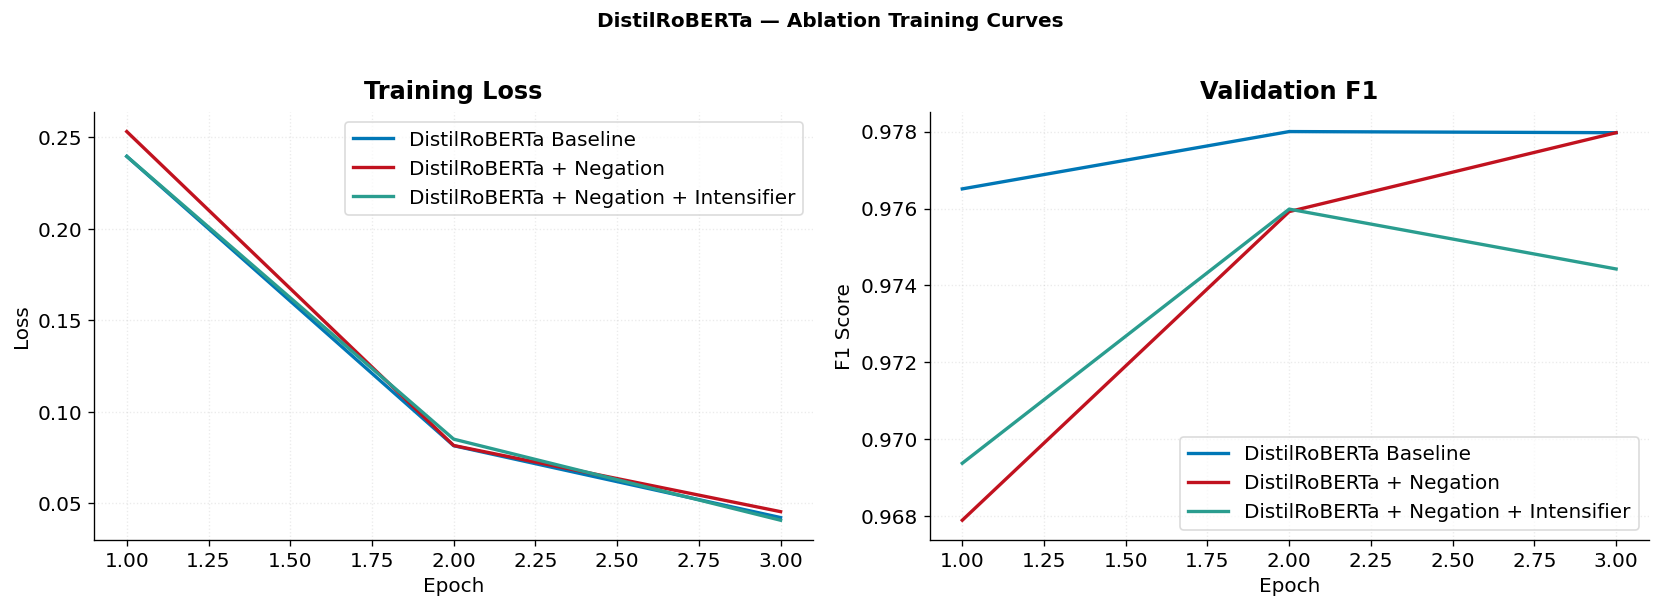

In [12]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#0077B6', '#C1121F', '#2A9D8F']

for hist, name, c in zip(
    [hist_base, hist_neg, hist_full],
    [name_base, name_neg, name_full],
    colors
):
    axes[0].plot(
        hist['epoch'],
        hist['train_loss'],
        label=name,
        color=c,
        linewidth=2
    )

    axes[1].plot(
        hist['epoch'],
        hist['val_f1'],
        label=name,
        color=c,
        linewidth=2
    )

for ax, title, ylabel in zip(
    axes,
    ['Training Loss', 'Validation F1'],
    ['Loss', 'F1 Score']
):
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(framealpha=0.7)

plt.suptitle(
    'DistilRoBERTa — Ablation Training Curves',
    fontsize=12,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig(
    DISTILROBERTA_PLT_DIR / 'training_curves.png',
    bbox_inches='tight'
)
plt.show()

## Ablation Confusion Matrices

Confusion matrices are used to analyse class-wise prediction performance for each experimental configuration. These visualisations provide insight into misclassification patterns and the model’s ability to distinguish between classes.

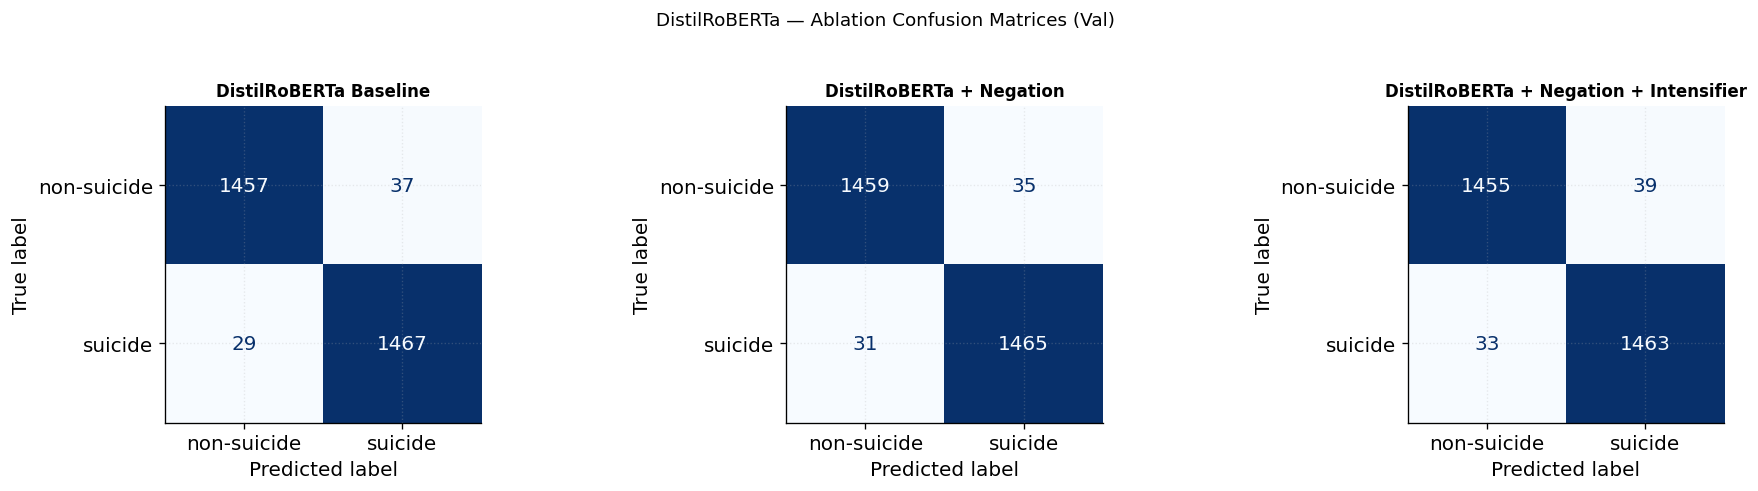

In [13]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, m in zip(
    axes,
    [name_base, name_neg, name_full],
    [val_base, val_neg, val_full]
):
    ConfusionMatrixDisplay(
        confusion_matrix(m['labels'], m['preds']),
        display_labels=['non-suicide', 'suicide']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('DistilRoBERTa — Ablation Confusion Matrices (Val)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(DISTILROBERTA_PLT_DIR / 'ablation_cm.png', bbox_inches='tight')
plt.show()

## Early Detection Analysis

This experiment evaluates model performance under limited input conditions by progressively truncating the text. It simulates early detection scenarios where only partial information is available, analysing how performance degrades as input length decreases.

Performance is assessed using F1-score, recall, and ROC-AUC across different input window sizes.

window= 32  F1=0.9705  recall=0.9533
window= 64  F1=0.9779  recall=0.9727
window=128  F1=0.9800  recall=0.9793


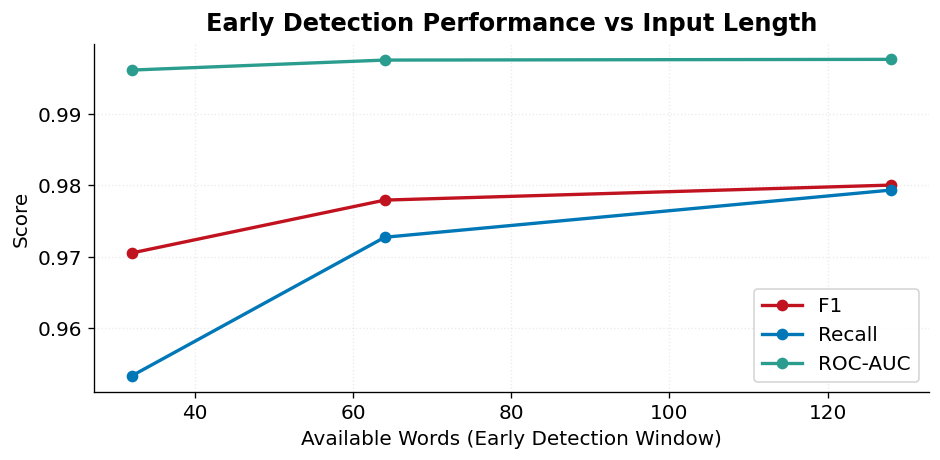

In [14]:
# Helper to truncate text to first n words
def truncate_words(text, n):
    return ' '.join(str(text).split()[:n])

# Evaluate performance across early detection windows
early_results = []

for window in EARLY_DETECTION_WINDOWS:
    test_trunc = test.copy()
    
    # Truncate input text
    test_trunc['text_clean'] = test_trunc['text_clean'].apply(
        lambda x: truncate_words(x, window)
    )
    
    # Prepare dataset and loader
    ds = SuicideDataset(test_trunc, tokenizer, 'text_clean', max_length=MAX_LENGTH)
    ldr = DataLoader(ds, batch_size=BATCH_SIZE * 2, collate_fn=collator)
    
    # Evaluate model
    m = evaluate_epoch(model_base, ldr, nn.CrossEntropyLoss(), DEVICE)
    
    early_results.append({
        'window': window,
        'F1': round(m['f1'], 4),
        'Recall': round(m['recall'], 4),
        'ROC-AUC': round(m['roc_auc'], 4)
    })
    print(f'window={window:>3}  F1={m["f1"]:.4f}  recall={m["recall"]:.4f}')

# Convert to DataFrame
early_df = pd.DataFrame(early_results)

# Plot early detection performance
fig, ax = plt.subplots(figsize=(8, 4))

for col, color in [
    ('F1', '#C1121F'),
    ('Recall', '#0077B6'),
    ('ROC-AUC', '#2A9D8F')
]:
    ax.plot(
        early_df['window'],
        early_df[col],
        marker='o',
        label=col,
        color=color,
        linewidth=2
    )

ax.set_xlabel('Available Words (Early Detection Window)')
ax.set_ylabel('Score')
ax.set_title('Early Detection Performance', fontweight='bold', pad=8)
ax.legend()

ax.set_title('Early Detection Performance vs Input Length', fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig(DISTILROBERTA_PLT_DIR / 'early_detection.png', bbox_inches='tight')
plt.show()

## Best Model Selection and Test Evaluation

The best-performing configuration is selected based on validation F1-score. The selected model is then evaluated on the test set to obtain unbiased performance metrics.

Predictions, probabilities, and results are stored for reproducibility and further analysis.

In [15]:
# Select best experiment based on validation F1
best_idx = ablation_df['F1'].idxmax()
best_condition = ablation_df.loc[best_idx, 'Experiment']

print(f'Best condition: {best_condition}')

# Map experiment to model and configuration
best_map = {
    name_base: (model_base, 'text_clean', False),
    name_neg:  (model_neg,  'text_neg_tagged', False),
    name_full: (model_full, 'text_neg_tagged', True)
}

bm, bc, bi = best_map[best_condition]

# Prepare test dataset
test_ds = SuicideDataset(
    test,
    tokenizer,
    text_col=bc,
    max_length=MAX_LENGTH,
    use_intensifier=bi
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE * 2,
    collate_fn=collator
)

# Evaluate on test set
test_metrics = evaluate_epoch(
    bm,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE
)

# Print classification report
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=['non-suicide', 'suicide']
))

# Save predictions and results
with open(DISTILROBERTA_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'ablation': ablation_df,
        'test_preds': test_metrics['preds'],
        'test_labels': test_metrics['labels'],
        'test_probs': test_metrics['probs'],
        'best_condition': best_condition
    }, f)

ablation_df.to_csv(DISTILROBERTA_RESULTS_CSV, index=False)

Best condition: DistilRoBERTa Baseline
              precision    recall  f1-score   support

 non-suicide       0.98      0.98      0.98      1498
     suicide       0.98      0.98      0.98      1500

    accuracy                           0.98      2998
   macro avg       0.98      0.98      0.98      2998
weighted avg       0.98      0.98      0.98      2998

